In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED, DenHaanMarcet
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression import TemplateConfig, PySRParams, ModelParametrizer

from sympy import Matrix, Float, preorder_traversal
from warnings import catch_warnings, simplefilter

from numpy import log
import numpy as np

from scipy.linalg import cholesky, solve_triangular
from scipy.stats import t
from sklearn.metrics import r2_score

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import cProfile

_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

def walk_round(x, n=3):
    for atom in preorder_traversal(x):
        if isinstance(atom, Float):
            x = x.subs(atom, round(atom, n))
    return x

def OLS(y, X, intercept=True):
    if intercept:
        X = np.column_stack([np.ones(X.shape[0]), X])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fit = X @ beta
    resid = y - fit
    r2 = r2_score(y, fit)
    return beta, fit, resid, r2

def t_test_significance(resid, X, beta, intercept=True, return_se=False):
    if intercept:
        X = np.column_stack([np.ones(X.shape[0]), X])
    n, k = X.shape
    sigma2 = np.sum(resid**2) / (n - k)
    var_beta = sigma2 * np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(np.diag(var_beta))
    t_stats = beta / se_beta
    p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=n - k))
    if return_se:
        return t_stats, p_values, se_beta
    return t_stats, p_values

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# Load reference model
parser = ModelParser("../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [3]:
# Load Misspecified DGP
parser_dgp = ModelParser("../MODELS/misspec_test/misspec.yaml")
config_dgp, kalman_dgp = parser_dgp.get_all()
solver_dgp = DSGESolver(config_dgp, kalman_dgp)
comp_dgp = solver_dgp.compile(
    n_state=3,
    n_exog=3,
)
sol_dgp = solver_dgp.solve(
    comp_dgp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [4]:
T = 200
gz_gen = lambda seed: Shock(T, "norm", multivar=True, seed=seed).shock_generator()
r_gen = lambda seed: Shock(T, "norm", multivar=False, seed=seed).shock_generator()

sim_dgp = sol_dgp.sim(
    T=T,
    shocks={"g,z": gz_gen(0), "r": r_gen(1)},
    observables=True,
)

In [5]:
# Use DGP observables as kalman filter targets in reference model
obs = np.column_stack([sim_dgp["OutGap"], sim_dgp["Infl"], sim_dgp["Rate"]])[1:, :]
kf = sol.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
)

N, n_obs = kf.innov.shape
std_innov = np.empty_like(kf.innov)

for t in range(N):
    S_t = 0.5 * (kf.S[t] + kf.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov[t] = solve_triangular(L_t, kf.innov[t], lower=True)

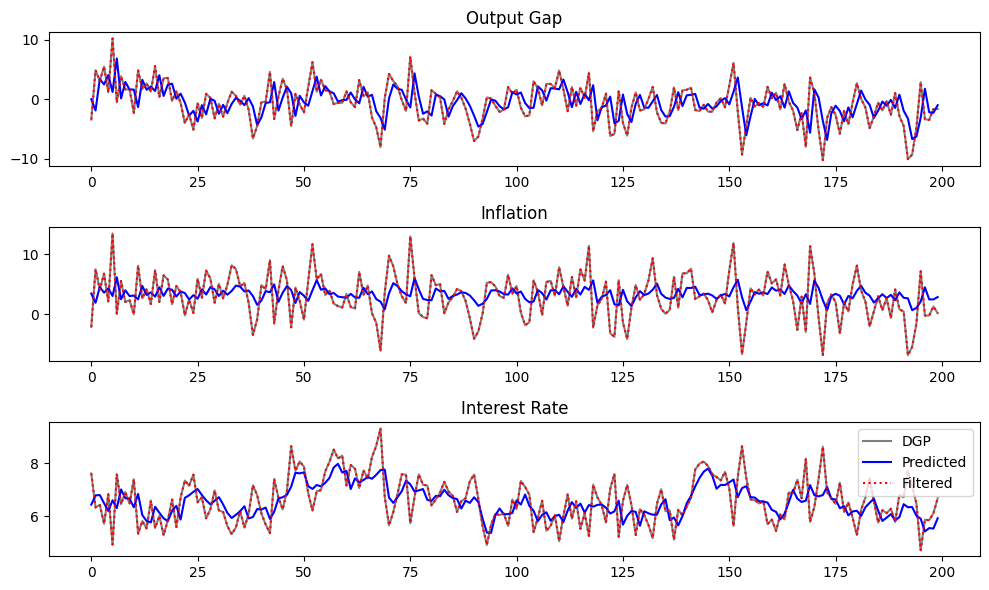

In [6]:
# Plot Filter Outputs
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.5)
ax[0].plot(range(T), kf.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.5)
ax[1].plot(range(T), kf.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.5)
ax[2].plot(range(T), kf.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

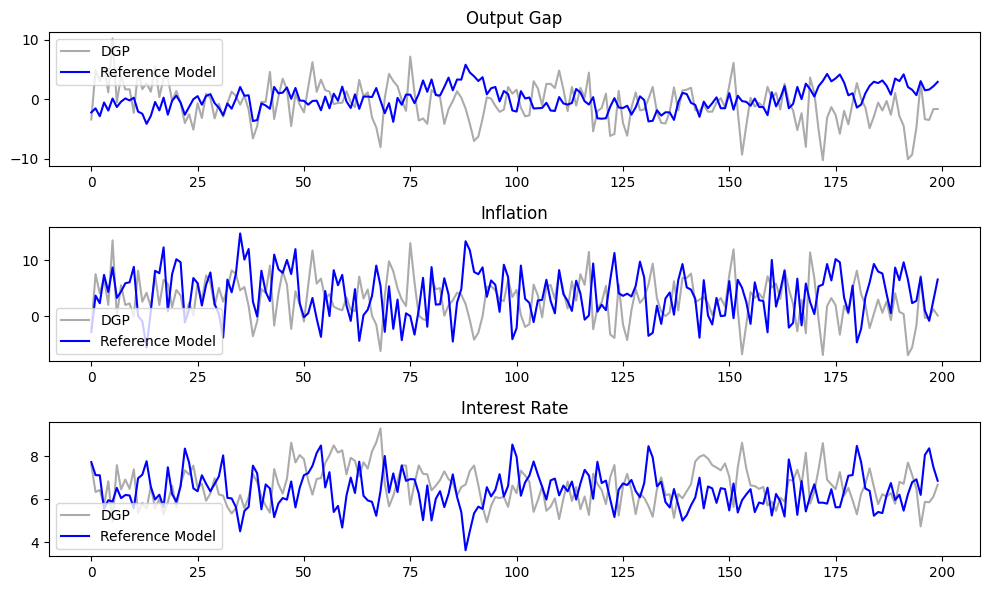

In [7]:
# Simulation against DGP
sim_ref = sol.sim(
    T=T,
    shocks={"g,z": gz_gen(2), "r": r_gen(3)},
    observables=True,
)

ref = np.column_stack([sim_ref["OutGap"], sim_ref["Infl"], sim_ref["Rate"]])[1:, :]

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), ref[:, 0], label="Reference Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), ref[:, 1], label="Reference Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), ref[:, 2], label="Reference Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

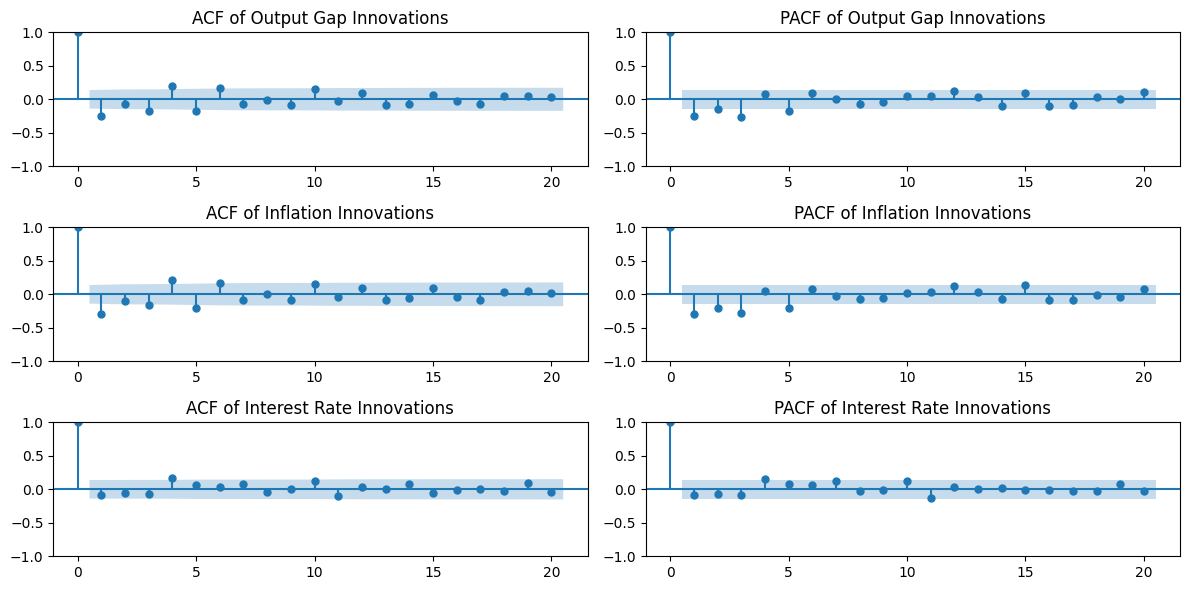

Ljung-Box test for Output Gap Innovations:
    LB Stat=13.19
    p-value=0.0003

Ljung-Box test for Inflation Innovations:
    LB Stat=17.59
    p-value=0.0000

Ljung-Box test for Interest Rate Innovations:
    LB Stat=1.55
    p-value=0.2131



In [8]:
# Plot AFC/PACF of kalman innovations to see if the misspecification appears in the form of serial correlation

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov[:, 0], ax=ax[0, 0], lags=20)
plot_pacf(std_innov[:, 0], ax=ax[0, 1], lags=20)
ax[0, 0].set_title("ACF of Output Gap Innovations")
ax[0, 1].set_title("PACF of Output Gap Innovations")

plot_acf(std_innov[:, 1], ax=ax[1, 0], lags=20)
plot_pacf(std_innov[:, 1], ax=ax[1, 1], lags=20)
ax[1, 0].set_title("ACF of Inflation Innovations")
ax[1, 1].set_title("PACF of Inflation Innovations")

plot_acf(std_innov[:, 2], ax=ax[2, 0], lags=20)
plot_pacf(std_innov[:, 2], ax=ax[2, 1], lags=20)
ax[2, 0].set_title("ACF of Interest Rate Innovations")
ax[2, 1].set_title("PACF of Interest Rate Innovations")

plt.tight_layout()
plt.show()
# Apply Ljung-Box test to check for serial correlation in innovations
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = acorr_ljungbox(std_innov[:, i], lags=20)
    print(
        f"Ljung-Box test for {var} Innovations:\n    LB Stat={test['lb_stat'].iloc[0]:.2f}\n    p-value={test['lb_pvalue'].iloc[0]:.4f}\n"
    )

In [79]:
mu = std_innov.mean(axis=0)
Sigma = np.cov(std_innov, rowvar=False)

print("Mean:", mu)
print("Covariance:\n", Sigma)

Mean: [-0.13626054  0.08251774  0.04166615]
Covariance:
 [[ 5.52742602 -5.89740045  1.55990654]
 [-5.89740045  6.81130768 -1.64079109]
 [ 1.55990654 -1.64079109  1.40687451]]


In [10]:
from scipy.stats import t
# OLS regression of innovations against predicted states (orthogonalized)
beta_pi_orth, _, Pi_orth, r2_Pi_orth = OLS(kf.x_pred[:, 4], kf.x_pred[:, [2, 3]])  # x_pred[:, g, z, r, x]
beta_x_orth, _, x_orth, r2_X_orth = OLS(kf.x_pred[:, 3], kf.x_pred[:, [2, 4]])  # x_pred[:, g, z, r, Pi]
beta_r_orth, _, r_orth, r2_r_orth = OLS(kf.x_pred[:, 2], kf.x_pred[:, [3, 4]])  # x_pred[:, g, z, x, Pi]

t_pi_orth, p_pi_orth, se_pi_orth = t_test_significance(Pi_orth, kf.x_pred[:, [2, 3]], beta_pi_orth, return_se=True)
t_x_orth, p_x_orth, se_x_orth = t_test_significance(x_orth, kf.x_pred[:, [2, 4]], beta_x_orth, return_se=True)
t_r_orth, p_r_orth, se_r_orth = t_test_significance(r_orth, kf.x_pred[:, [3, 4]], beta_r_orth, return_se=True)

df_summary = pd.DataFrame(
    {
        "Variable": ["Pi_orth", "x_orth", "r_orth"],
        "R^2": [r2_Pi_orth, r2_X_orth, r2_r_orth],
        "t-stat": [t_pi_orth[1], t_x_orth[1], t_r_orth[1]],
        "p-value": [p_pi_orth[1], p_x_orth[1], p_r_orth[1]],
        "Std. Error": [se_pi_orth[1], se_x_orth[1], se_r_orth[1]],
    }
)

Pi_orth = Pi_orth.reshape(-1, 1)
x_orth = x_orth.reshape(-1, 1)
r_orth = r_orth.reshape(-1, 1)

df_summary.round(3)

,Variable,R^2,t-stat,p-value,Std. Error
0,Pi_orth,0.736,-1.178,0.240,0.068
1,x_orth,0.735,0.416,0.678,0.581
2,r_orth,0.014,0.416,0.678,0.009


In [11]:
from scipy.stats import t
# Regress on measurement predictions
X = np.column_stack([r_orth, x_orth, Pi_orth])

beta_r_ogap, _, resid_r_ogap, _ = OLS(kf.innov[:, 0], X[:, 0].reshape(-1, 1))
t_r_ogap, p_r_ogap, se_r_ogap = t_test_significance(resid_r_ogap, X[:, 0].reshape(-1, 1), beta_r_ogap, return_se=True)

beta_x_ogap, _, resid_x_ogap, _ = OLS(kf.innov[:, 0], X[:, 1].reshape(-1, 1))
t_x_ogap, p_x_ogap, se_x_ogap = t_test_significance(resid_x_ogap, X[:, 1].reshape(-1, 1), beta_x_ogap, return_se=True)

beta_Pi_ogap, _, resid_Pi_ogap, _ = OLS(kf.innov[:, 0], X[:, 2].reshape(-1, 1))
t_Pi_ogap, p_Pi_ogap, se_Pi_ogap = t_test_significance(resid_Pi_ogap, X[:, 2].reshape(-1, 1), beta_Pi_ogap, return_se=True)

beta_r_infl, _, resid_r_infl, _ = OLS(kf.innov[:, 1], X[:, 0].reshape(-1, 1))
t_r_infl, p_r_infl, se_r_infl = t_test_significance(resid_r_infl, X[:, 0].reshape(-1, 1), beta_r_infl, return_se=True)

beta_x_infl, _, resid_x_infl, _ = OLS(kf.innov[:, 1], X[:, 1].reshape(-1, 1))
t_x_infl, p_x_infl, se_x_infl = t_test_significance(resid_x_infl, X[:, 1].reshape(-1, 1), beta_x_infl, return_se=True)

beta_Pi_infl, _, resid_Pi_infl, _ = OLS(kf.innov[:, 1], X[:, 2].reshape(-1, 1))
t_Pi_infl, p_Pi_infl, se_Pi_infl = t_test_significance(resid_Pi_infl, X[:, 2].reshape(-1, 1), beta_Pi_infl, return_se=True)

beta_r_rate, _, resid_r_rate, _ = OLS(kf.innov[:, 2], X[:, 0].reshape(-1, 1))
t_r_rate, p_r_rate, se_r_rate = t_test_significance(resid_r_rate, X[:, 0].reshape(-1, 1), beta_r_rate, return_se=True)

beta_x_rate, _, resid_x_rate, _ = OLS(kf.innov[:, 2], X[:, 1].reshape(-1, 1))
t_x_rate, p_x_rate, se_x_rate = t_test_significance(resid_x_rate, X[:, 1].reshape(-1, 1), beta_x_rate, return_se=True)

beta_Pi_rate, _, resid_Pi_rate, _ = OLS(kf.innov[:, 2], X[:, 2].reshape(-1, 1))
t_Pi_rate, p_Pi_rate, se_Pi_rate = t_test_significance(resid_Pi_rate, X[:, 2].reshape(-1, 1), beta_Pi_rate, return_se=True)

coef_mat = pd.DataFrame(
    {
        "OutGap": [beta_r_ogap[1], beta_x_ogap[1], beta_Pi_ogap[1]],
        "Infl": [beta_r_infl[1], beta_x_infl[1], beta_Pi_infl[1]],
        "Rate": [beta_r_rate[1], beta_x_rate[1], beta_Pi_rate[1]],
    },
    index=["r", "x", "Pi"],
)

t_mat = pd.DataFrame(
    {
        "OutGap": [p_r_ogap[0], p_x_ogap[0], p_Pi_ogap[0]],
        "Infl": [p_r_infl[0], p_x_infl[0], p_Pi_infl[0]],
        "Rate": [p_r_rate[0], p_x_rate[0], p_Pi_rate[0]],
    },
    index=["r", "x", "Pi"],
)

se_mat = pd.DataFrame(
    {
        "OutGap": [se_r_ogap[0], se_x_ogap[0], se_Pi_ogap[0]],
        "Infl": [se_r_infl[0], se_x_infl[0], se_Pi_infl[0]],
        "Rate": [se_r_rate[0], se_x_rate[0], se_Pi_rate[0]],
    },
    index=["r", "x", "Pi"],
)

print("OLS Coefficients of Innovations on Predicted States (Orthogonalized):\n")
print(coef_mat.round(3))

print("\nP-values from t-tests on Coefficients:\n")
print(t_mat.round(3))

print("\nStandard Errors of Coefficients:\n")
print(se_mat.round(3))

OLS Coefficients of Innovations on Predicted States (Orthogonalized):

    OutGap   Infl   Rate
r    0.218  0.244  0.101
x    0.114  0.139  0.008
Pi  -5.396 -1.815  0.115

P-values from t-tests on Coefficients:

    OutGap   Infl   Rate
r    0.396  0.205  0.105
x    0.395  0.205  0.105
Pi   0.384  0.204  0.105

Standard Errors of Coefficients:

    OutGap   Infl   Rate
r    0.222  0.257  0.047
x    0.222  0.257  0.047
Pi   0.216  0.256  0.047


In [12]:
print(np.var(r_orth), np.var(x_orth), np.var(Pi_orth))
print(np.linalg.norm(r_orth), np.linalg.norm(x_orth), np.linalg.norm(Pi_orth))

0.018228623056967715 1.212670164194081 0.016790674023708933
1.9093780692658915 15.573504192660566 1.8325214336377589


In [13]:
print(np.corrcoef(Pi_orth.reshape(-1), kf.innov[:,0])[0,1])
print(np.corrcoef(Pi_orth.reshape(-1), kf.innov[:,1])[0,1])
print(np.corrcoef(Pi_orth.reshape(-1), kf.innov[:,2])[0,1])

-0.22371502500899887
-0.06508393344005438
0.02265640560245504


In [14]:
# Innovation Regression Tests
Pi = kf.x_pred[:, 4].reshape(-1, 1)
x = kf.x_pred[:, 3].reshape(-1, 1)
r = kf.x_pred[:, 2].reshape(-1, 1)


def regression_report(y_idx):
    y = kf.innov[:, y_idx]
    beta_Pi_innov_ogap, _, resid_Pi_innov_ogap, r2_Pi_ogap = OLS(y, Pi)
    t_Pi_innov_ogap, p_Pi_innov_ogap, se_Pi_innov_ogap = t_test_significance(
        resid_Pi_innov_ogap, Pi, beta_Pi_innov_ogap, return_se=True
    )
    beta_Pi_innov_ogap[1] = beta_Pi_innov_ogap[1] * (np.std(Pi)/np.std(y))

    beta_x_innov_ogap, _, resid_x_innov_ogap, r2_x_ogap = OLS(y, x)
    t_x_innov_ogap, p_x_innov_ogap, se_x_innov_ogap = t_test_significance(
        resid_x_innov_ogap, x, beta_x_innov_ogap, return_se=True
    )
    beta_x_innov_ogap[1] = beta_x_innov_ogap[1] * (np.std(x)/np.std(y))

    beta_r_innov_ogap, _, resid_r_innov_ogap, r2_r_ogap = OLS(y, r)
    t_r_innov_ogap, p_r_innov_ogap, se_r_innov_ogap = t_test_significance(
        resid_r_innov_ogap, r, beta_r_innov_ogap, return_se=True
    )
    beta_r_innov_ogap[1] = beta_r_innov_ogap[1] * (np.std(r)/np.std(y))

    ogap_data = pd.DataFrame(
        {
            "Std. Coef": [beta_Pi_innov_ogap[1], beta_x_innov_ogap[1], beta_r_innov_ogap[1]],
            "R^2": [r2_Pi_ogap, r2_x_ogap, r2_r_ogap],
            "Std. Error": [se_Pi_innov_ogap[0], se_x_innov_ogap[0], se_r_innov_ogap[0]],
            "t-stat": [t_Pi_innov_ogap[0], t_x_innov_ogap[0], t_r_innov_ogap[0]],
            "p-value": [p_Pi_innov_ogap[0], p_x_innov_ogap[0], p_r_innov_ogap[0]],
            
        },
        index=["Pi", "x", "r"],
    )
    return ogap_data

def regression_report_orth(y_idx):
    y = kf.innov[:, y_idx]
    beta_Pi_innov_ogap, _, resid_Pi_innov_ogap, r2_Pi_ogap = OLS(y, Pi_orth)
    t_Pi_innov_ogap, p_Pi_innov_ogap, se_Pi_innov_ogap = t_test_significance(
        resid_Pi_innov_ogap, Pi_orth, beta_Pi_innov_ogap, return_se=True
    )
    beta_Pi_innov_ogap[1] = beta_Pi_innov_ogap[1] * (np.std(Pi_orth)/np.std(y))

    beta_x_innov_ogap, _, resid_x_innov_ogap, r2_x_ogap = OLS(y, x_orth)
    t_x_innov_ogap, p_x_innov_ogap, se_x_innov_ogap = t_test_significance(
        resid_x_innov_ogap, x_orth, beta_x_innov_ogap, return_se=True
    )
    beta_x_innov_ogap[1] = beta_x_innov_ogap[1] * (np.std(x_orth)/np.std(y))

    beta_r_innov_ogap, _, resid_r_innov_ogap, r2_r_ogap = OLS(y, r_orth)
    t_r_innov_ogap, p_r_innov_ogap, se_r_innov_ogap = t_test_significance(
        resid_r_innov_ogap, r_orth, beta_r_innov_ogap, return_se=True
    )
    beta_r_innov_ogap[1] = beta_r_innov_ogap[1] * (np.std(r_orth)/np.std(y))
    
    ogap_data = pd.DataFrame(
        {
            "Std. Coef": [beta_Pi_innov_ogap[1], beta_x_innov_ogap[1], beta_r_innov_ogap[1]],
            "R^2": [r2_Pi_ogap, r2_x_ogap, r2_r_ogap],
            "Std. Error": [se_Pi_innov_ogap[0], se_x_innov_ogap[0], se_r_innov_ogap[0]],
            "t-stat": [t_Pi_innov_ogap[0], t_x_innov_ogap[0], t_r_innov_ogap[0]],
            "p-value": [p_Pi_innov_ogap[0], p_x_innov_ogap[0], p_r_innov_ogap[0]],
            
        },
        index=["Pi", "x", "r"],
    )
    return ogap_data

# Ogap
print("Regression of Output Gap Innovations on Predicted States:\n")
print(regression_report(0).round(3))
print("\nRegression of Output Gap Innovations on Predicted States (Orthogonalized):\n")
print(regression_report_orth(0).round(3))
print("\n\n")

# Inflation
print("Regression of Inflation Innovations on Predicted States:\n")
print(regression_report(1).round(3))
print("\nRegression of Inflation Innovations on Predicted States (Orthogonalized):\n")
print(regression_report_orth(1).round(3))
print("\n\n")

# Interest Rate
print("Regression of Interest Rate Innovations on Predicted States:\n")
print(regression_report(2).round(3))
print("\nRegression of Interest Rate Innovations on Predicted States (Orthogonalized):\n")
print(regression_report_orth(2).round(3))

Regression of Output Gap Innovations on Predicted States:

    Std. Coef    R^2  Std. Error  t-stat  p-value
Pi     -0.370  0.137       0.208  -1.537    0.126
x      -0.296  0.088       0.218  -1.876    0.062
r       0.052  0.003       0.225  -0.970    0.333

Regression of Output Gap Innovations on Predicted States (Orthogonalized):

    Std. Coef    R^2  Std. Error  t-stat  p-value
Pi     -0.224  0.050       0.216  -0.873    0.384
x       0.040  0.002       0.222  -0.852    0.395
r       0.009  0.000       0.222  -0.851    0.396



Regression of Inflation Innovations on Predicted States:

    Std. Coef    R^2  Std. Error  t-stat  p-value
Pi     -0.057  0.003       0.258  -1.356    0.177
x      -0.027  0.001       0.264  -1.325    0.187
r       0.017  0.000       0.261  -1.294    0.197

Regression of Inflation Innovations on Predicted States (Orthogonalized):

    Std. Coef    R^2  Std. Error  t-stat  p-value
Pi     -0.065  0.004       0.256  -1.275    0.204
x       0.042  0.002       

Notice that output gap measurement regressions show Pi has retained a non-zero coefficient post-orthogonalization. This shows that the OLS based diagnostic identifies that Pi should exist in some capacity within the output gap measurement. Knowing that the planted misspecification was exactly `OutGap = OutGap + 2Pi(t)` the OLS finding is correctly identifying the equation/variable pair and localizing the misspecification correctly.

We know Pi(t) should be tested as a component of OutGap based on this result. However, the OLS coefficient is not solved under the complete RE system. Hence the coefficient itself is not reliable. Therefore, we will include Pi(t) in the measurement with a estimated coefficient, keeping all other parameters constant.

The model below defines a variable `Pi_coef = 0.0`. (We know the coefficient should be 2.0 but a real-life application should use a high-entropy prior assuming $H_0: \beta_{\Pi}=0$) We then estimate the coefficient and inspect the results.

In [58]:
parser_aug = ModelParser("../MODELS/misspec_test/augmented_reference.yaml")
config_aug, kalman_aug = parser_aug.get_all()
solver_aug = DSGESolver(config_aug, kalman_aug)
comp_aug = solver_aug.compile(
    n_state=3,
    n_exog=3,
)
priors = {
    "Pi_coef": make_prior(
        'normal',
        parameters={"mean": 0.0, "std": 4.0, "random_state":0,},
        transform="identity",  # Keep the coefficient unconstrained
    ),
}

estim = lambda: solver_aug.estimate_and_solve(
    compiled=comp_aug,
    method="mcmc",
    n_draws=25_000,
    burn_in=10_000,
    thin=2,
    posterior_point="mean",
    proposal_scale=1.0,  # Default=0.1 - increased to allow for more exploration given the high-entropy prior
    y=obs,
    priors=priors,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    log_linear=False,
    random_state=0,
)
res_aug, sol_aug = estim()

MCMC sampling concluded in 84.55 seconds with 709.66 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [59]:
sol_aug.config.calibration.parameters["Pi_coef"]

np.float64(1.91428282876443)

In [60]:
res_aug.hpd_intervals()

{'Pi_coef': (np.float64(1.784208496069326), np.float64(2.042169157517201))}

The estimation results are quite successful even under the very loose prior. The coefficient of the misspecification term is almost exactly recovered by this methodology. In a real life scenario, however, we would not be aware of that at this point. Therefore we should confirm the validity of the recovered parameter. To do so, we run through the same OLS diagnostics and KF checks. But we can also estimate the measurement error as a shorthand, crude check. With this coefficient, the augmented model is almost 1-to-1 with the misspecified DGP, therefore an estimated $R$ matrix (measurement error covariance) should be very close to 0 in this case.

In [63]:
kf_aug = sol_aug.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
)
kf_aug.loglik

-782.9014279057081

Before further checks, a test to see if SR could've discovered the same term will be conducted. With strong multicollinearity between model states, SR may converge to a completely different solution utilizing different variables. A quick test can tell us what the results would've looked like with SR.

In [18]:
template_config = TemplateConfig(
    include_expression=False,
    hessian_restriction="free",
    interaction_form="func",
    constant_filtering="keep",
    model_complexity_bound=12,
)

params = PySRParams(
    maxsize=12,
    niterations=250,
    binary_operators=["+", "-", "*"],
    should_optimize_constants=True,
    should_simplify=True,
    deterministic=True,
    parallelism="serial",
    random_state=0,
    verbosity=0,
)

res = sol.fit_kf(
    y=obs,
    observable="OutGap",
    template_config=template_config,
    sr_params=params,
    variables=["Pi"]
)
res.expressions["initial_expr"] = res.expressions["initial_expr"].apply(walk_round)

/Users/guneykiymac/Desktop/Portfolio/SymbolicDSGE/.venv/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [19]:
res.expressions[["complexity", "initial_expr", "loss"]]

,complexity,initial_expr,loss
0,1,-0.189,9.767109
1,2,-4.441*Pi,8.531286
2,3,-4.582*Pi - 0.319,8.430675
3,5,Pi*(-2.949*Pi - 4.69),8.401436
4,7,2*Pi*(-Pi - 2.441) - 0.244,8.384098
5,8,-2.325*Pi*(Pi + 1.612) - Pi - 0.174,8.379498
6,9,Pi*(-2.317*Pi - 3.747) - Pi - 0.174,8.379496
7,10,-3.431*(Pi + 0.637)*(Pi**2 + 1.178) + 2.393,8.369098


SR fails to discover the misspecification correctly in this case. This is expected when we leave the coefficients and constants discovered by the model as-is. We can parametrize the constants and estimate each expression outputted. In which case, since the misspecification term is known, we can conclude that the second expression ($\beta \Pi(t)$) would very likely yield the best diagnostic outcome.

## Diagnostics of the Augmented Model

We will continue with the parameter-estimated augmentation and formalize the fact that the misspecification was correctly discovered within margins. To do so, we will run all of the tests that were ran for the initial misspecified model and conduct a comparison of outcomes.

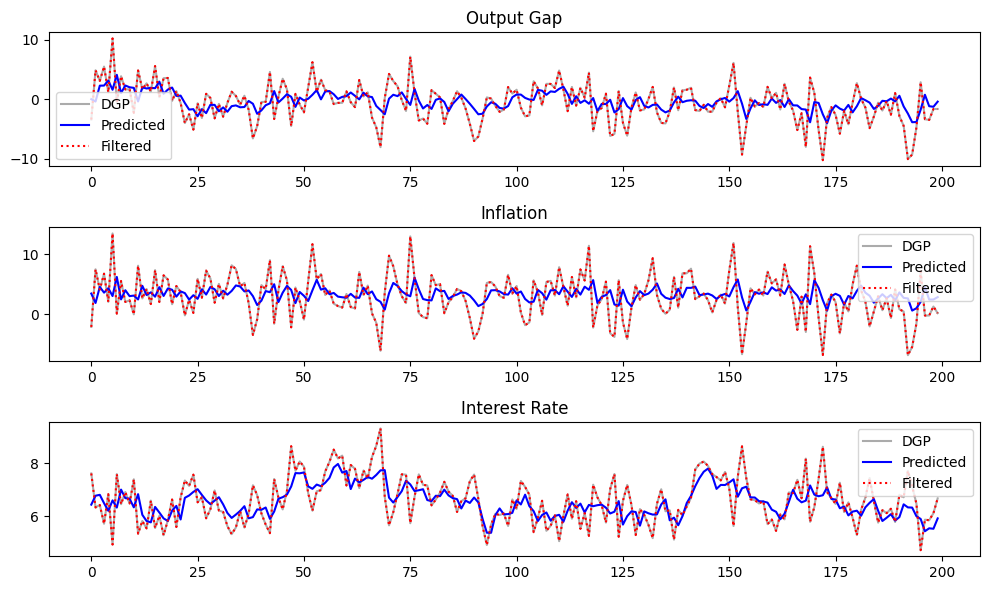

In [20]:
# Plot KF Outputs for Augmented Model
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)
ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), kf_aug.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf_aug.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), kf_aug.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf_aug.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1]. set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), kf_aug.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf_aug.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

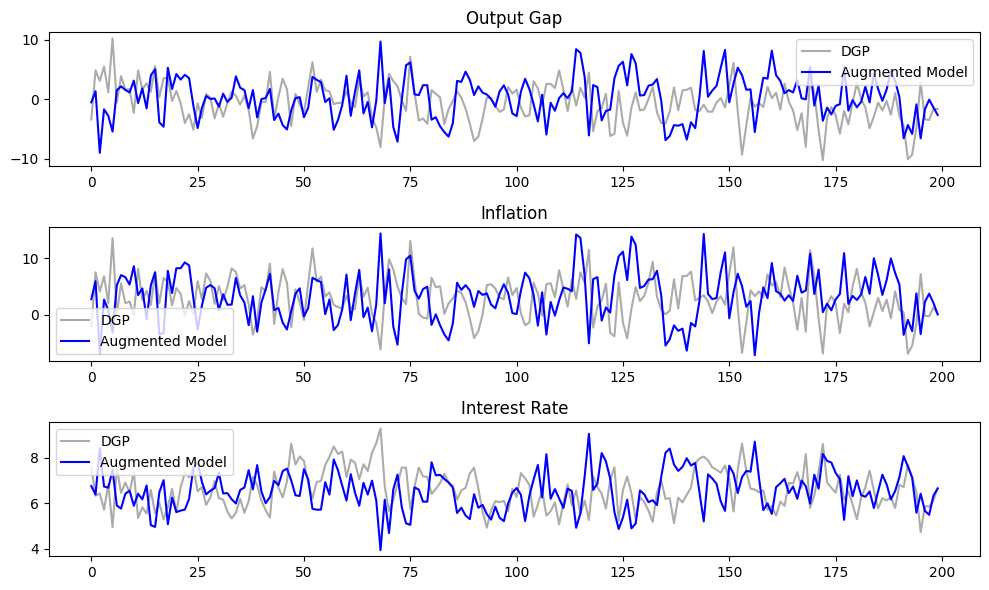

In [21]:
# Simulation against DGP for Augmented Model

sim_aug = sol_aug.sim(
    T=T,
    shocks={"g,z": gz_gen(4), "r": r_gen(5)},
    observables=True,
)
aug = np.column_stack([sim_aug["OutGap"], sim_aug["Infl"], sim_aug["Rate"]])[1:, :]
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), aug[:, 0], label="Augmented Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), aug[:, 1], label="Augmented Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), aug[:, 2], label="Augmented Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

### Simulation Accuracy Test

We now have realized simulations representing the DGP and Augmentation. We can conduct a Den Haan - Marcet test to determine whether the DGP-simulated states are statistically distinguishable from the Augmented Model class. This test is a simulation test targetting the laws of motion, which we know are identical between the DGP and Augmented model. Therefore we expect a clean pass and a p-value of 1.0 here. This is applied as a consistency check before the measurement residuals are test.

In [22]:
dhm = DenHaanMarcet(sol_dgp)  # Initialize test space with DGP, this means the misspecification is embedded in the FOCs
res = dhm.from_state_path(
    states=sim_aug["_X"],
    equation_idx=[0, 1, 2],  # Test first-orders, not the AR(1) shock propagation equations
    instrument_idx=[0,1,2,3,4],  # All instruments
    use_conditional_expectation=True, # (t+1) variables computed as deterministic law of motion (shock=0) at time t.
)
res.p_value

1.0

### Marginal LR Test Conditional on $\theta_0$

We can conduct a LR test holding parameters of the $\theta_0$ constant among models and DGP to assess the marginal likelihood contribution of the added component.

In [54]:
from scipy.stats import chi2
res_mle, sol_mle = solver_aug.estimate_and_solve(
    compiled=comp_aug,
    method="mle",
    y=obs,
    estimated_params=["Pi_coef"],
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)
mle_aug_kf = sol_mle.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
)

l_aug = mle_aug_kf.loglik
l_raw = kf.loglik

lr = 2 * (l_aug - l_raw)
print(f"Log-Likelihood of Raw Reference Model: {l_raw:.2f}")
print(f"Log-Likelihood of Augmented Model: {l_aug:.2f}")
print(f"Likelihood Ratio Statistic: {lr:.2f}")
p_value_lr = 1 - chi2.cdf(lr, df=1)  # one addirional parameter in augmented model
print(f"P-value of LR Test: {p_value_lr:.4f}")

[Estimator:mle] BK stability warnings encountered during search: 0
Log-Likelihood of Raw Reference Model: -1876.71
Log-Likelihood of Augmented Model: -782.71
Likelihood Ratio Statistic: 2188.01
P-value of LR Test: 0.0000


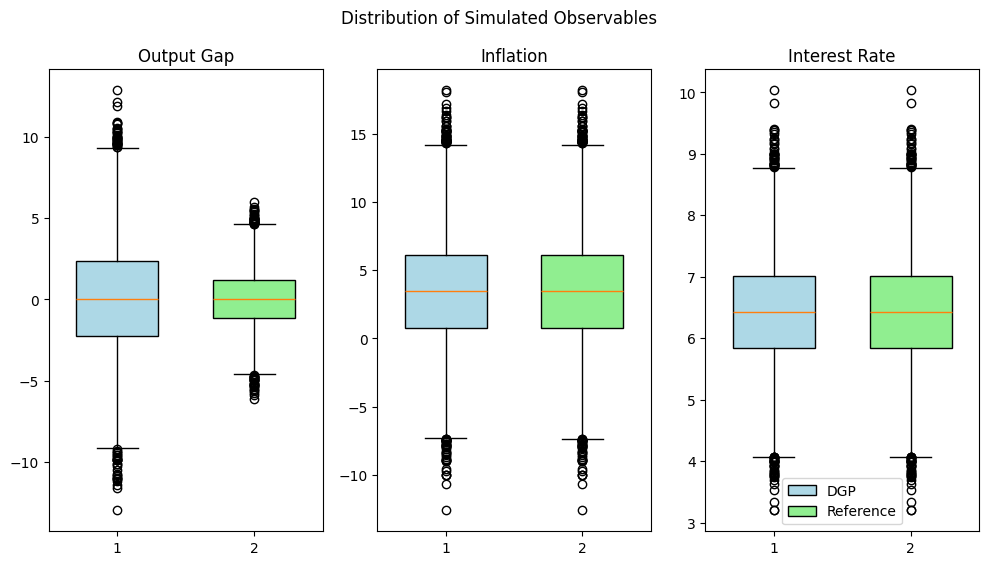

In [24]:
gz_large = lambda seed: Shock(10_000, "norm", multivar=True, seed=seed).shock_generator()
r_large = lambda seed: Shock(10_000, "norm", multivar=False, seed=seed).shock_generator()
shocks_large = {"g,z": gz_large(6), "r": r_large(7)}

sim1 = sol_dgp.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)
sim2 = sol.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

fig, ax = plt.subplots(1, 3, figsize=_FIGSIZE_2D)

plt.suptitle("Distribution of Simulated Observables")

ax[0].boxplot(sim1["OutGap"], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[0].boxplot(sim2["OutGap"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[0].set_title("Output Gap")

ax[1].boxplot(sim1["Infl"], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[1].boxplot(sim2["Infl"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[1].set_title("Inflation")

ax[2].boxplot(sim1["Rate"], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[2].boxplot(sim2["Rate"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[2].set_title("Interest Rate")
ax[2].legend()

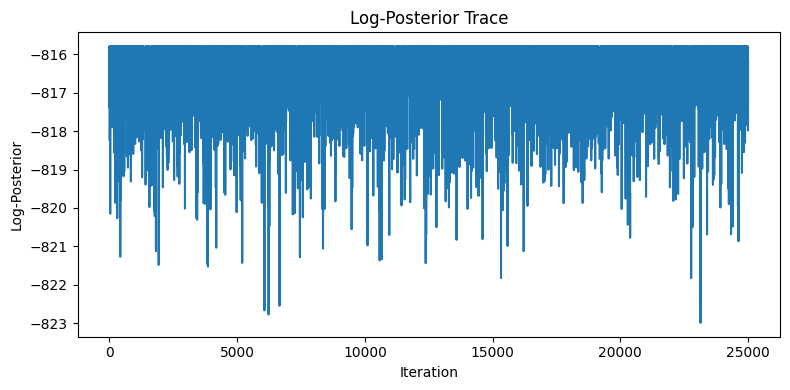

In [25]:
res_aug.logpost_trace_plot()

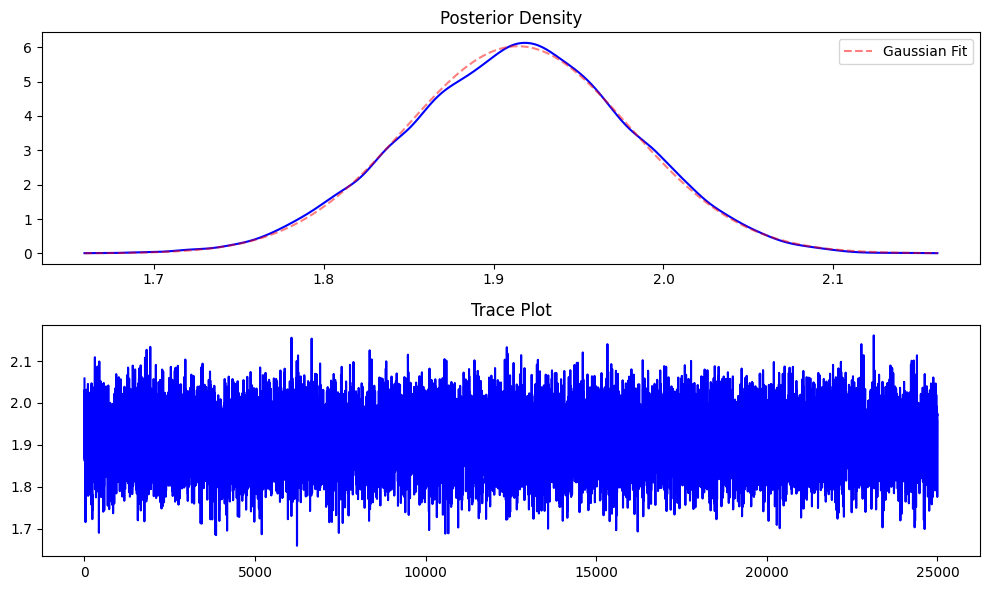

In [76]:
from scipy.stats import gaussian_kde, norm
pi_coeff_trace = res_aug.samples[:, 0]

kde = gaussian_kde(pi_coeff_trace)
norm_fit = norm(loc=pi_coeff_trace.mean(), scale=pi_coeff_trace.std())
x_range = np.linspace(pi_coeff_trace.min(), pi_coeff_trace.max(), 1000)
fig, ax = plt.subplots(2, 1, figsize=_FIGSIZE_1D)

ax[0].plot(x_range, kde(x_range), color="blue")
ax[0].plot(x_range, norm_fit.pdf(x_range), linestyle="--", color="red", alpha=0.5, label="Gaussian Fit")
ax[0]
ax[0].set_title("Posterior Density")
ax[0].legend()

ax[1].plot(pi_coeff_trace, color="blue")
ax[1].set_title("Trace Plot")

plt.tight_layout()
plt.show()

In [55]:
res_mle

OptimizationResult(kind='mle', x=array([1.94162169]), theta={'beta': np.float64(0.971), 'kappa': np.float64(0.58), 'tau_inv': np.float64(1.86), 'psi_pi': np.float64(2.19), 'psi_x': np.float64(0.3), 'rho_r': np.float64(0.84), 'rho_g': np.float64(0.83), 'rho_z': np.float64(0.85), 'pi_star': np.float64(3.43), 'r_star': np.float64(3.01), 'sig_r': np.float64(0.18), 'sig_g': np.float64(0.18), 'sig_z': np.float64(0.64), 'rho_gz': np.float64(0.36), 'meas_infl': np.float64(1e-06), 'meas_rate': np.float64(1e-06), 'meas_outgap': np.float64(1e-06), 'meas_rho_ir': np.float64(0.0), 'meas_rho_gi': np.float64(0.0), 'meas_rho_gr': np.float64(0.0), 'Pi_coef': np.float64(1.9416216861696662)}, success=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', fun=np.float64(783.5878729457801), loglik=np.float64(-783.5878729457801), logprior=np.float64(0.0), logpost=np.float64(-783.5878729457801), nfev=8, nit=2, raw=  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True


## Serial Autocorrelation tests for the Augmented Model

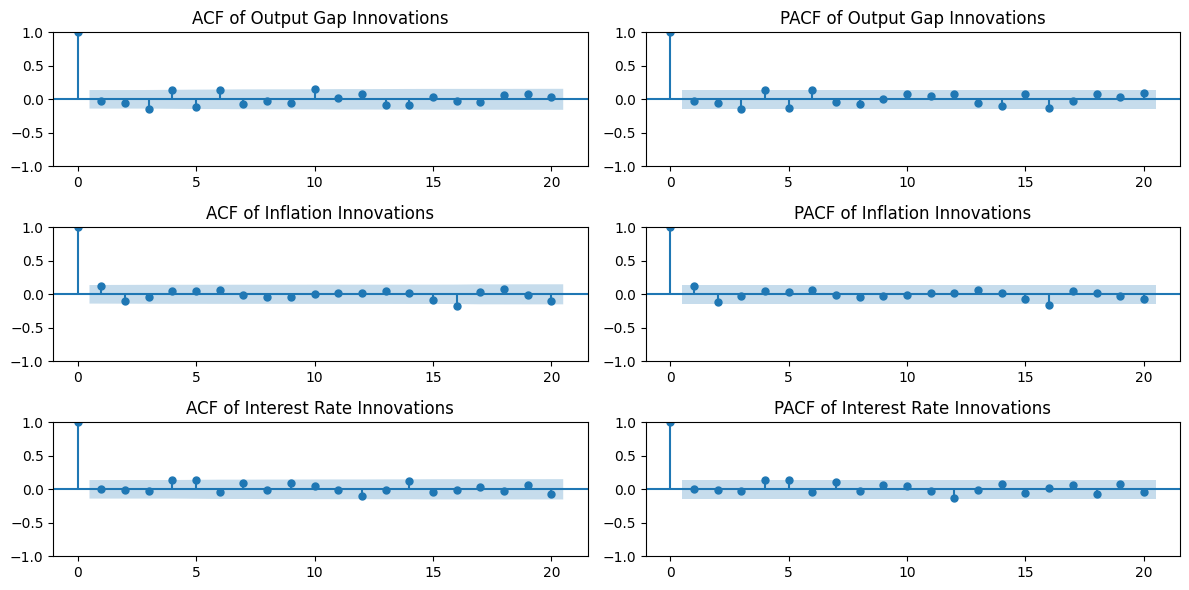

Ljung-Box test for Output Gap Innovations (Augmented Model):
    LB Stat=0.09
    p-value=0.7649

Ljung-Box test for Inflation Innovations (Augmented Model):
    LB Stat=2.77
    p-value=0.0961

Ljung-Box test for Interest Rate Innovations (Augmented Model):
    LB Stat=0.03
    p-value=0.8696



In [72]:
std_innov_aug = np.empty_like(kf_aug.innov)
for t in range(N):
    S_t = 0.5 * (kf_aug.S[t] + kf_aug.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov_aug[t] = solve_triangular(L_t, kf_aug.innov[t], lower=True)

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov_aug[:, 0], ax=ax[0, 0], lags=20, title="ACF of Output Gap Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 0], ax=ax[0, 1], lags=20, title="PACF of Output Gap Innovations", label="Augmented Model")

plot_acf(std_innov_aug[:, 1], ax=ax[1, 0], lags=20, title="ACF of Inflation Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 1], ax=ax[1, 1], lags=20, title="PACF of Inflation Innovations", label="Augmented Model")

plot_acf(std_innov_aug[:, 2], ax=ax[2, 0], lags=20, title="ACF of Interest Rate Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 2], ax=ax[2, 1], lags=20, title="PACF of Interest Rate Innovations", label="Augmented Model")


plt.tight_layout()
plt.show()

# Ljung-Box test for Augmented Model Innovations
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = acorr_ljungbox(std_innov_aug[:, i], lags=20)
    print(
        f"Ljung-Box test for {var} Innovations (Augmented Model):\n    LB Stat={test['lb_stat'].iloc[0]:.2f}\n    p-value={test['lb_pvalue'].iloc[0]:.4f}\n"
    )

In [78]:
mu_aug = std_innov_aug.mean(axis=0)
Sigma_aug = np.cov(std_innov_aug, rowvar=False)

print("Mean of Augmented Model Innovations:", mu_aug)
print("Covariance of Augmented Model Innovations:\n", Sigma_aug.round(3))

Mean of Augmented Model Innovations: [-0.0957059   0.06794004  0.05485199]
Covariance of Augmented Model Innovations:
 [[ 0.878 -0.073  0.067]
 [-0.073  0.939  0.03 ]
 [ 0.067  0.03   0.945]]


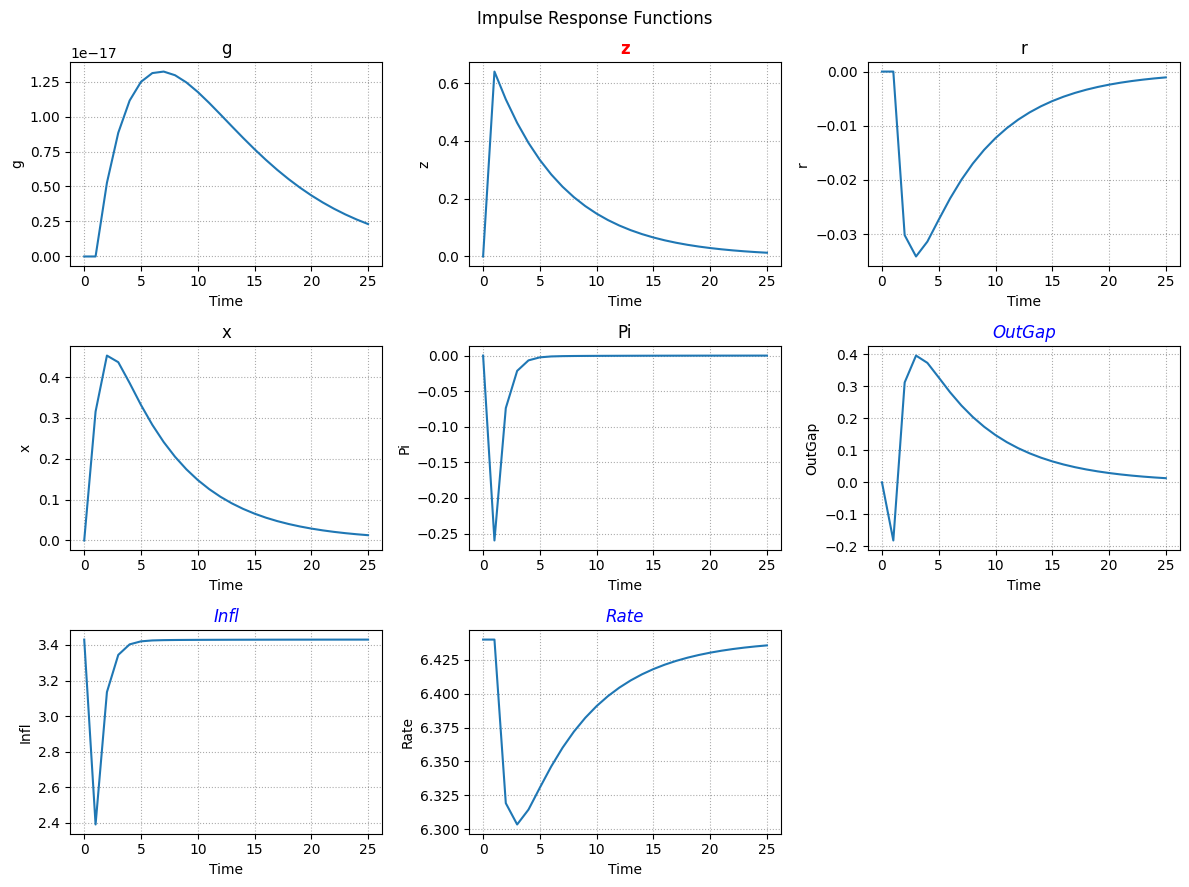

In [81]:
sol_aug.transition_plot(
    T=25,
    observables=True,
    shocks=["z"],
    scale=1.0,
)